# **Тема 7. Численное решение уравнения f(x)=0 методом хорд и касательных**

**Мой вариант:**

image.png

In [ ]:

import numpy as np

def f(x):
    return 2**x - 2*x**2 - 1

def df(x):
    return np.log(2) * (2**x) - 4*x

def ddf(x):
    return (np.log(2)**2) * (2**x) - 4

def method_newton(x0, eps=1e-8, max_iter=100):
    """Метод касательных"""
    x = x0
    for i in range(max_iter):
        fx = f(x)
        dfx = df(x)
        if abs(dfx) < 1e-12:
            return None, None
        x_new = x - fx / dfx
        if abs(x_new - x) < eps:
            return x_new, i + 1
        x = x_new
    return None, None

def method_secant(a, b, eps=1e-8, max_iter=100):
    """Метод хорд"""
    fa, fb = f(a), f(b)
    if fa * fb >= 0:
        return None, None
    x0, x1 = a, b
    for i in range(max_iter):
        fx0, fx1 = f(x0), f(x1)
        denom = fx1 - fx0
        if abs(denom) < 1e-12:
            return None, None
        x_new = x1 - fx1 * (x1 - x0) / denom
        if abs(x_new - x1) < eps:
            return x_new, i + 1
        x0, x1 = x1, x_new
    return None, None

def isolate_positive_roots(x_start=0.0, x_end=1000.0, step=0.01):
    """положительные корни"""
    intervals = []
    x = x_start
    while x < x_end:
        x_next = x + step
        if f(x) == 0:
            intervals.append((x, x))
        elif f(x) * f(x_next) < 0:
            intervals.append((x, x_next))
        x = x_next
    return intervals

def main():
    eps = 1e-10
    intervals = isolate_positive_roots(x_start=0.0, x_end=1000.0, step=0.01)
    print("Найденные интервалы с корнями:", intervals)
    print(f"Точность вычислений: {eps}")

    roots = []
    for a, b in intervals:
        if a == b:
            root = a
            method_used = "точное значение"
        else:
            mid = (a + b) / 2
            f1 = df(mid)
            f2 = ddf(mid)

            if f1 * f2 > 0:
                root, iters = method_newton(b, eps=eps)
                method_used = "метод касательных"
            else:
                root, iters = method_secant(a, b, eps=eps)
                method_used = "метод хорд"

            if root is None:
                continue


        precision = max(1, int(-np.log10(eps)))
        root_rounded = round(root, precision)

        if root > 0 and not any(abs(root - r) < eps for r in roots):
            roots.append(root)
            print(f"Найден корень: x = {root:.{precision}f} ({method_used})")

    if not roots:
        print("Положительные корни не найдены на [0, 100].")
    else:
        print(f"\nВсе положительные корни: {sorted(roots)}")
if __name__ == "__main__":
    main()

Найденные интервалы с корнями: [(0.0, 0.0), (0.3900000000000002, 0.4000000000000002), (6.349999999999909, 6.359999999999909)]
Точность вычислений: 1e-10
Найден корень: x = 0.3992807567 (метод касательных)
Найден корень: x = 6.3523448924 (метод касательных)

Все положительные корни: [np.float64(0.39928075666163765), np.float64(6.3523448924341155)]


In [ ]:
import numpy as np

def f(x):
    return 2**x - 2*x**2 - 1

def df(x):
    return np.log(2) * (2**x) - 4*x

def isolate_positive_roots(x_start=0.0, x_end=10.0, step=0.01):
    intervals = []
    x = x_start
    while x < x_end:
        x_next = x + step
        if abs(f(x)) < 1e-12:
            intervals.append((x, x))
        elif f(x) * f(x_next) < 0:
            intervals.append((x, x_next))
        x = x_next
    return intervals

def method_secant(a, b, eps=1e-10, max_iter=100):
    fa, fb = f(a), f(b)
    if fa * fb >= 0:
        return None, None

    x0, x1 = a, b

    for i in range(max_iter):
        fx0, fx1 = f(x0), f(x1)

        if abs(fx1) < 0.1:
            dfx1 = df(x1)
            if abs(dfx1) > 1e-14:
                # метод касательных
                x_newton = x1
                for j in range(max_iter - i):
                    fx = f(x_newton)
                    dfx = df(x_newton)
                    if abs(dfx) < 1e-14:
                        break
                    x_next = x_newton - fx / dfx
                    if abs(x_next - x_newton) < eps:
                        return x_next, i + j + 1
                    x_newton = x_next
                # если Ньютон не сошёлся — продолжаем хордами

        # метод хорд
        denom = fx1 - fx0
        if abs(denom) < 1e-14:
            return None, None
        x_new = x1 - fx1 * (x1 - x0) / denom

        if abs(x_new - x1) < eps:
            return x_new, i + 1

        x0, x1 = x1, x_new

    return None, None

def main():
    eps = 1e-15
    intervals = isolate_positive_roots(x_start=0.0, x_end=10.0, step=0.5)
    print("Найденные интервалы с корнями:", intervals)
    print(f"Точность вычислений: {eps}")

    roots = []
    for a, b in intervals:
        if a == b or abs(f(a)) < eps:
            root = a
            method_used = "точное значение"
        else:
            root, iters = method_secant(a, b, eps=eps)
            method_used = "метод хорд с использованием касательных"
            if root is None:
                continue

        precision = max(1, int(-np.log10(eps)))
        if root is not None and root > 0 and not any(abs(root - r) < eps for r in roots):
            roots.append(root)
            print(f"Найден корень: x = {root:.{precision}f} ({method_used})")

    if not roots:
        print("Положительные корни не найдены на [0, 10].")
    else:
        print(f"\nВсе положительные корни: {sorted(roots)}")

if __name__ == "__main__":
    main()

Найденные интервалы с корнями: [(0.0, 0.0), (6.0, 6.5)]
Точность вычислений: 1e-15
Найден корень: x = 6.352344892434115 (метод хорд с использованием касательных)

Все положительные корни: [np.float64(6.3523448924341155)]


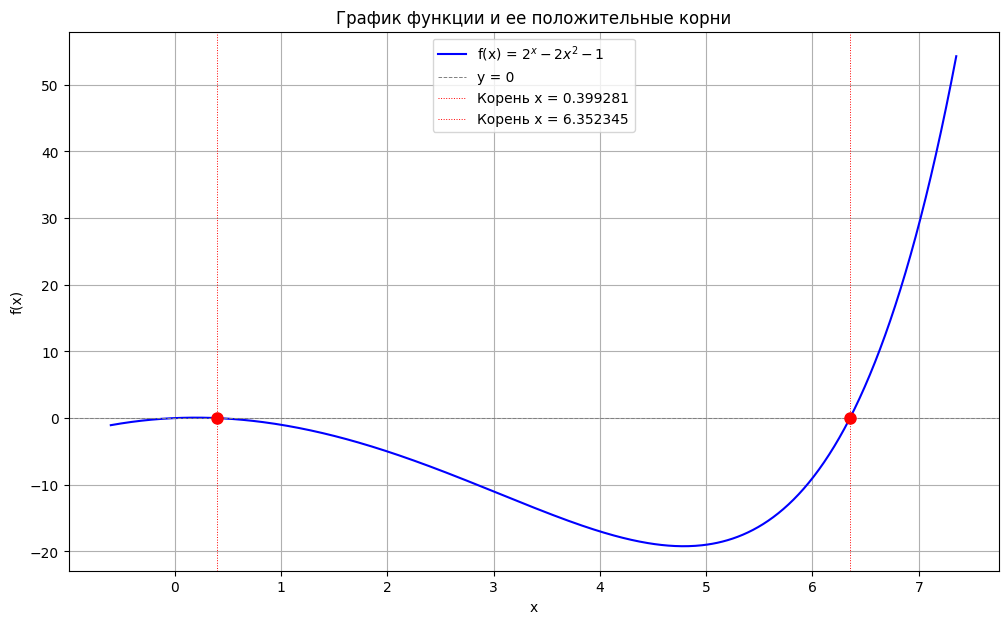

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def f(x):
    return 2**x - 2*x**2 - 1

def plot_function_and_roots(roots_list):

    if roots_list:
        x_min = min(roots_list) - 1.0
        x_max = max(roots_list) + 1.0
    else:
        x_min = -1.0
        x_max = 7.0

    x_vals = np.linspace(x_min, x_max, 500)
    y_vals = f(x_vals)

    plt.figure(figsize=(12, 7))
    plt.plot(x_vals, y_vals, label='f(x) = $2^x - 2x^2 - 1$', color='blue')
    plt.axhline(0, color='gray', linestyle='--', linewidth=0.7, label='y = 0')

    if roots_list:
        for i, root in enumerate(roots_list):
            plt.plot(root, f(root), 'ro', markersize=8)
            plt.axvline(root, color='red', linestyle=':', linewidth=0.7, label=f'Корень x = {root:.6f}')

    plt.title('График функции и ее положительные корни')
    plt.xlabel('x')
    plt.ylabel('f(x)')
    plt.grid(True)
    plt.legend()
    plt.show()

plot_function_and_roots(roots)


In [ ]:
import numpy as np

def f(x):
    return 2**x - 2*x**2 - 1

def df(x):
    return np.log(2) * (2**x) - 4*x

def ddf(x):
    return (np.log(2)**2) * (2**x) - 4

def combined_method(x0_newton, x0_secant, eps=1e-8, max_iter=100):


    x_n = x0_newton
    x_s = x0_secant


    if f(x_n) * f(x_s) >= 0:
        print("Предупреждение: f(x_n) и f(x_s) должны иметь разные знаки для метода хорд")

    history = []

    for i in range(max_iter):

        history.append({
            'iteration': i + 1,
            'x_newton': x_n,
            'x_secant': x_s,
            'f_newton': f(x_n),
            'f_secant': f(x_s)
        })

        fx_n = f(x_n)
        dfx_n = df(x_n)

        if abs(dfx_n) < 1e-15:
            print(f"Производная близка к нулю на итерации {i+1}")
            return x_n, x_s, i + 1, history

        x_n_new = x_n - fx_n / dfx_n


        fx_s = f(x_s)
        fx_n_prev = f(x_n)

        denom = fx_s - fx_n_prev
        if abs(denom) < 1e-15:
            print(f"Знаменатель близок к нулю на итерации {i+1}")
            return x_n, x_s, i + 1, history

        x_s_new = x_s - fx_s * (x_s - x_n) / denom

        newton_diff = abs(x_n_new - x_n)
        secant_diff = abs(x_s_new - x_s)
        between_diff = abs(x_n_new - x_s_new)

        if (newton_diff < eps and secant_diff < eps) or between_diff < eps:

            x_n, x_s = x_n_new, x_s_new
            history.append({
                'iteration': i + 2,
                'x_newton': x_n,
                'x_secant': x_s,
                'f_newton': f(x_n),
                'f_secant': f(x_s)
            })
            return x_n, x_s, i + 1, history

        x_n, x_s = x_n_new, x_s_new

    print(f"Достигнуто максимальное число итераций ({max_iter})")
    return x_n, x_s, max_iter, history

def isolate_positive_roots(x_start=0.0, x_end=10.0, step=0.1):
    """Изолируем интервалы с положительными корнями"""
    intervals = []
    x = x_start
    while x < x_end:
        x_next = x + step
        if f(x) == 0:
            intervals.append((x, x))
        elif f(x) * f(x_next) < 0:
            intervals.append((x, x_next))
        x = x_next
    return intervals

def find_initial_points(a, b):

    mid = (a + b) / 2
    f1 = df(mid)
    f2 = ddf(mid)

    if f1 * f2 > 0:
        return b, a
    else:

        return a, b

def main():
    eps = 1e-10

    intervals = isolate_positive_roots(x_start=0.0, x_end=100.0, step=0.01)
    print("Найденные интервалы с корнями:", intervals)

    roots = []

    for a, b in intervals:
        if a == b:

            roots.append(round(a, 10))
            print(f"Найден точный корень: x = {a:.10f}")
            continue


        x0_newton, x0_secant = find_initial_points(a, b)

        print(f"\n Решение для интервала [{a:.3f}, {b:.3f}]")
        print(f"Начальные точки: x_newton = {x0_newton:.6f}, x_secant = {x0_secant:.6f}")
        print(f"f(x_newton) = {f(x0_newton):.6e}, f(x_secant) = {f(x0_secant):.6e}")


        x_newton, x_secant, iterations, history = combined_method(
            x0_newton, x0_secant, eps=eps, max_iter=100
        )


        root = (x_newton + x_secant) / 2


        if abs(f(root)) < 1e-6:
            root_rounded = round(root, 10)
            if not any(abs(root_rounded - r) < eps for r in roots):
                roots.append(root_rounded)

                print(f"\nРезультат:")
                print(f"  Метод касательных: x = {x_newton:.15f}, f(x) = {f(x_newton):.3e}")
                print(f"  Метод хорд:        x = {x_secant:.15f}, f(x) = {f(x_secant):.3e}")
                print(f"  Среднее значение:  x = {root:.15f}, f(x) = {f(root):.3e}")
                print(f"  Итераций: {iterations}")


                print(f"\nИстория итераций (первые 5 и последние 5):")
                for i, h in enumerate(history[:5] + (history[-5:] if len(history) > 10 else history[5:])):
                    print(f"  Итерация {h['iteration']}: "
                          f"Ньютон = {h['x_newton']:.10f} (f={h['f_newton']:.3e}), "
                          f"Хорд = {h['x_secant']:.10f} (f={h['f_secant']:.3e})")

    if not roots:
        print("\nПоложительные корни не найдены на [0, 100].")
    else:
        print(f"\nВсе найденные положительные корни: {sorted(roots)}")

        print("\nПроверка корней:")
        for root in sorted(roots):
            print(f"  x = {root:.10f}, f(x) = {f(root):.15e}")

if __name__ == "__main__":
    main()


Найденные интервалы с корнями: [(0.0, 0.0), (0.3900000000000002, 0.4000000000000002), (6.349999999999909, 6.359999999999909)]
Найден точный корень: x = 0.0000000000

 Решение для интервала [0.390, 0.400]
Начальные точки: x_newton = 0.400000, x_secant = 0.390000
f(x_newton) = -4.920892e-04, f(x_secant) = 6.193404e-03

Результат:
  Метод касательных: x = 0.399280756665614, f(x) = -2.716e-12
  Метод хорд:        x = 0.399280756609001, f(x) = 3.595e-11
  Среднее значение:  x = 0.399280756637308, f(x) = 1.662e-11
  Итераций: 2

История итераций (первые 5 и последние 5):
  Итерация 1: Ньютон = 0.4000000000 (f=-4.921e-04), Хорд = 0.3900000000 (f=6.193e-03)
  Итерация 2: Ньютон = 0.3992820270 (f=-8.676e-07), Хорд = 0.3992639448 (f=1.148e-05)
  Итерация 3: Ньютон = 0.3992807567 (f=-2.716e-12), Хорд = 0.3992807566 (f=3.595e-11)

 Решение для интервала [6.350, 6.360]
Начальные точки: x_newton = 6.360000, x_secant = 6.350000
f(x_newton) = 2.400574e-01, f(x_secant) = -7.311985e-02

Результат:
  Мет